In [ ]:
import os, sys, json, time, cv2
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage   as ndi
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from datetime import datetime
from PIL import Image

sys.path.append('../../..')
from Synthetic.index import SyntheticGenerator
from Nature.index    import NatureSelector

sys.path.append('../../../')
from Model.utils.index import getFiles, showTile

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# DATASETS

In [18]:
marlim = {
    'calm': getFiles('../Marlim/files/calm'),
    'dead': getFiles('../Marlim/files/dead'),
    'faulted': getFiles('../Marlim/files/faulted')
}

# CLASSE DE SEMELHANÇA

In [22]:
class imageSimilarity:
    def __init__(self):
        pass

    # FAZ O CÁLCULO PARA DUAS IMAGENS (2D/3D)
    def get(self, img1, img2):
        pass

    # PEGA A MÉDIA DA SIMILIARIDADE GERAL ENTRE DOIS DATASETS COM IMAGENS (2D/3D)
    def datasets(path1, path2):
        pass

    # PLOTA AS DUAS IMAGENS E O TITULO É A SIMILARIDADE ENTRE ELAS
    def plot(self, img1, img2):
        similarity = self.get(self, img1, img2)
        plt.figure(figsize=(15, 4))
        plt.subplot(1, 2, 1)
        showTile(img1)
        plt.subplot(1, 2, 2)
        showTile(img2)
        plt.title(f'{similarity*100:.2f}% de similaridade')
        plt.show()


img1 = np.load(marlim['calm'][0])
img2 = np.load(marlim['dead'][0])

similarity = imageSimilarity()
similarity.plot(img1, img2)

TypeError: imageSimilarity.get() takes 3 positional arguments but 4 were given

# GERADOR SINTÉTICO

TypeError: Invalid shape (2, 128, 128, 128) for image data

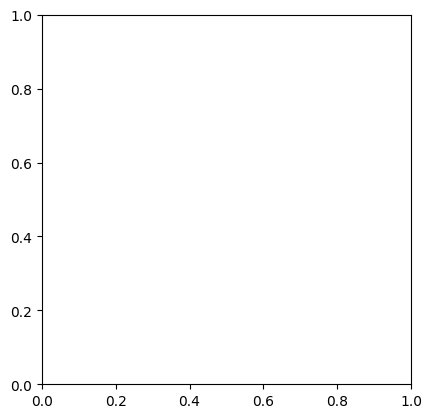

In [19]:
REFERENCE = {
    'calm': {
        'layerLow': 69,
        'layerSpan': 54,
        'thickLow': 1,
        'thickSpan': 1,
        'foldLow': 42,
        'foldSpan': 35,
        'foldSigmaLow': 34.95287,
        'foldSigmaSpan': 31.02391,
        'foldAmpLow': -21.71672,
        'foldAmpSpan': 1.4896,
        'foldDamping': 0.2,
        'shearLow': -0.0955,
        'shearSpan': 0.3763,
        'faultLow': 0,
        'faultSpan': 1,
        'freqLow': 61.95206,
        'freqSpan': 285.31752,
        'duration': 0.095,
        'noiseLow': 0.05,
        'noiseSpan': 0.15,
        'noiseSmooth': 3.0,
        'noiseInline': 2.0,
        'gainJitter': 0.26
    },
    'faulted': {
        'layerLow': 65,
        'layerSpan': 24,
        'thickLow': 6,
        'thickSpan': 9,
        'foldLow': 23,
        'foldSpan': 13,
        'foldSigmaLow': 7.82473,
        'foldSigmaSpan': 50.19,
        'foldAmpLow': -10.07881,
        'foldAmpSpan': 15.6538,
        'foldDamping': 3.9936,
        'shearLow': -0.3546,
        'shearSpan': 0.7,
        'faultLow': 3,
        'faultSpan': 3,
        'freqLow': 38.48694,
        'freqSpan': 56.08668,
        'duration': 0.24,
        'noiseLow': 0.0374,
        'noiseSpan': 0.1449,
        'noiseSmooth': 1.0,
        'noiseInline': 1.0,
        'gainJitter': 0.26
    },
    'dead': {
        'layerLow': 420,
        'layerSpan': 264,
        'thickLow': 7,
        'thickSpan': 1,
        'foldLow': 35,
        'foldSpan': 35,
        'foldSigmaLow': 20.71,
        'foldSigmaSpan': 5.18,
        'foldAmpLow': 3.24,
        'foldAmpSpan': 44.44,
        'foldDamping': 2.9344,
        'shearLow': -0.3078,
        'shearSpan': 0.7,
        'faultLow': 0,
        'faultSpan': 1,
        'freqLow': 32.98,
        'freqSpan': 1.67,
        'duration': 0.0257,
        'noiseLow': 0.12,
        'noiseSpan': 0.28,
        'noiseSmooth': 2.0,
        'noiseInline': 1.0,
        'gainJitter': 0.35
    }
}

generator = SyntheticGenerator()
generator.set(REFERENCE['calm'])
plt.imshow(generator.get())

# ALGORITMO OTIMIZADOR

In [ ]:
def objective(self, params, region='calm'):
    gen = SyntheticGenerator()
    gen.set(params)
    gen.dataset(f"files/{region}", n=20)
    return imageSimilarity().datasets(f'../Marlim/files/{region}', f'files/{region}')


SPACE = {
    'layerLow':      {'bounds': (10, 500),   'type': 'int'},   # camadas na coluna
    'layerSpan':     {'bounds': (1, 300),    'type': 'int'},
    'thickLow':      {'bounds': (1, 12),     'type': 'int'},   # espessura da camada, em voxels
    'thickSpan':     {'bounds': (1, 12),     'type': 'int'},
    'foldLow':       {'bounds': (2, 60),     'type': 'int'},   # nº de dobras
    'foldSpan':      {'bounds': (1, 40),     'type': 'int'},
    'foldSigmaLow':  {'bounds': (3.0, 80.0)},                  # largura da dobra
    'foldSigmaSpan': {'bounds': (1.0, 70.0)},
    'foldAmpLow':    {'bounds': (-50.0, 40.0)},                # altura da dobra
    'foldAmpSpan':   {'bounds': (0.0, 60.0)},
    'foldDamping':   {'bounds': (0.2, 6.0)},                   # perda da dobra com a profundidade
    'shearLow':      {'bounds': (-0.5, 0.2)},                  # mergulho regional
    'shearSpan':     {'bounds': (0.0, 0.7)},
    'faultLow':      {'bounds': (0, 3),      'type': 'int'},   # nº de falhas por tile
    'faultSpan':     {'bounds': (1, 3),      'type': 'int'},
    'freqLow':       {'bounds': (25.0, 333.0)},                # frequência da wavelet, na escala do dt=0.0012
    'freqSpan':      {'bounds': (0.0, 300.0)},
    'duration':      {'bounds': (0.018, 0.240)},               # duração da wavelet
    'noiseLow':      {'bounds': (0.0, 0.40)},                  # ruído: o que quebra a coerência do refletor
    'noiseSpan':     {'bounds': (0.0, 0.60)},
    'noiseSmooth':   {'bounds': (0.4, 5.0)},                   # grão do ruído na seção (z, xline)
    'noiseInline':   {'bounds': (0.4, 5.0)},                   # grão do ruído ao longo das inlines
    'gainJitter':    {'bounds': (0.0, 0.6)},                   # variação de contraste entre tiles
}

# OTIMIZAÇÃO - REGIÃO CALM

In [ ]:
problem = {
    'objective': lambda params: objective(params, 'calm'), 'maximize': True, 'seed': 42, 'verbose': True,
    'variables': SPACE['calm']
}

calm = NatureSelector('genetic', {**problem, 'population': 50, 'generations': 100, 'workers': 8, 'backend': 'process'}, n_gaussian=1)
best, score = calm.update()

calm.plotMetrics()
calm.plotVariables('range')
calm.plotVariables('temporal')

# OTIMIZAÇÃO - REGIÃO DEAD

In [ ]:
problem = {
    'objective': lambda params: objective(params, 'dead'), 'maximize': True, 'seed': 42, 'verbose': True,
    'variables': SPACE['dead']
}

dead = NatureSelector('genetic', {**problem, 'population': 50, 'generations': 100, 'workers': 8, 'backend': 'process'}, n_gaussian=1)
dead, score = calm.update()

dead.plotMetrics()
dead.plotVariables('range')
dead.plotVariables('temporal')

# OTIMIZAÇÃO - REGIÃO FAULTED

In [ ]:
problem = {
    'objective': lambda params: objective(params, 'faulted'), 'maximize': True, 'seed': 42, 'verbose': True,
    'variables': SPACE['faulted']
}

faulted = NatureSelector('genetic', {**problem, 'population': 50, 'generations': 100, 'workers': 8, 'backend': 'process'}, n_gaussian=1)
best, score = faulted.update()

faulted.plotMetrics()
faulted.plotVariables('range')
faulted.plotVariables('temporal')

# MÉTRICAS FINAIS

In [ ]:
REGIONS_OPTIMIZED = {
    'calm': calm.getBest(),
    'dead': dead.getBest(),
    'faulted': faulted.getBest()
}

In [ ]:
syntetic = {
    'calm': getFiles('files/calm'),
    'dead': getFiles('files/calm'),
    'faulted': getFiles('files/calm')
}

In [ ]:
results = {
    'calm': ImageSimilarity().datasets(marlim['calm'], syntetic['calm']),
    'dead': ImageSimilarity().datasets(marlim['dead'], syntetic['dead']),
    'faulted': ImageSimilarity().datasets(marlim['faulted'], syntetic['faulted']),
)

pd.DataFrame([results])

# GERANDO OS DADOS SINTETICOS NOVOS

In [ ]:
options = {
    'directory': f'../Dataset/marlim_regions',
    'regions': {
        'calm': {
            'n_images': 220, 
            'output': 'files/',
            'params': calm.getBest()
        },
        'dead': {
            'n_images': 220, 
            'output': 'files/',
            'params': dead.getBest()
        },
        'faulted': {
            'n_images': 220, 
            'output': 'files/',
            'params': faulted.getBest()
        },
    }
}

gen = SyntheticGenerator(seed=42)
gen.dataset(options)

NameError: name 'calm' is not defined

# VERIFICANDO SIMILARIDADE
- Calm

In [ ]:
for i in range(3):
    img1 = #regiao calm marlim

    img2 = np.load(getFiles('../../../Dataset/dataset_regions/original/calm/images')[i+3])
    msk2 = np.load(getFiles('../../../Dataset/dataset_regions/original/calm/masks')[i+3])
    imageSimilarity().plot(img1, img2); plt.imshow(msk2) # 3 colunas (marlim, sintetico mascara com falhas)
    

- Dead

- Faulted